# Mixture of Experts (MoE) 混合专家模型

Mixture of Experts 通过门控网络（Gating Network）将输入路由到少数专家网络（Experts），只激活部分参数，从而在扩大模型容量的同时控制计算成本。典型公式：

$$y = \sum_{i=1}^{k} G_i(x) \cdot E_i(x)$$

其中 $G_i(x)$ 是门控权重，$E_i(x)$ 是第 $i$ 个专家的输出，$k$ 通常远小于专家总数。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Expert network: a simple feed-forward (MLP) that will serve as one expert.
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Expert, self).__init__()
        # Define a two-layer MLP for the expert (you can use any architecture per expert)
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.activation = nn.ReLU()  # non-linear activation between layers

    def forward(self, x):
        # x: Tensor of shape (batch_subset, input_dim) for inputs routed to this expert
        # Hidden layer computation
        h = self.activation(self.layer1(x))
        # Output layer
        out = self.layer2(h)
        return out

# MoE layer: contains multiple experts and a gating network to route inputs to experts
class MoE(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim, num_experts, k=2):
        """
        input_dim: dimensionality of input features
        output_dim: dimensionality of output (usually same as input_dim if used in Transformer FFN)
        hidden_dim: hidden layer size for each expert network (e.g., FFN expansion size)
        num_experts: number of expert networks
        k: how many top experts to use for each input (k=1 or 2 in practice for sparsity)
        """
        super(MoE, self).__init__()
        self.num_experts = num_experts
        self.top_k = k
        self.output_dim = output_dim
        # Gating network: a linear layer that produces a score (logit) for each expert
        # Input: [*, input_dim] -> Output: [*, num_experts]
        self.gate = nn.Linear(input_dim, num_experts)
        # Expert networks: ModuleList of `num_experts` experts (each an independent network)
        self.experts = nn.ModuleList([
            Expert(input_dim, hidden_dim, output_dim) for _ in range(num_experts)
        ])

    def forward(self, x):
        # x: Tensor of shape (N, input_dim), where N is the batch size (or total tokens being routed)
        N = x.size(0)
        # 1. Gating: compute scores for each expert
        logits = self.gate(x)               # shape: (N, num_experts), raw scores for each expert
        # 2. Top-k Selection: select indices of the top k highest scores for each input
        topk_vals, topk_indices = torch.topk(logits, self.top_k, dim=1)  # both shapes: (N, k)
        # 3. Create a mask of the same shape as logits to zero-out all but top-k experts
        mask = torch.full_like(logits, float('-inf'))  # start with -inf for all positions
        mask.scatter_(1, topk_indices, topk_vals)      # place top-k values at their indices, others stay -inf
        # 4. Convert the masked logits to probabilities (softmax over the top-k experts only)
        gating_weights = F.softmax(mask, dim=1)        # shape: (N, num_experts); non-topk experts get 0 probability
        # (After this softmax, each input's weight distribution is mostly over its top-k experts)
        
        # 5. Prepare an output tensor (initialized to zero) 
        output = torch.zeros(N, self.output_dim, device=x.device)
        
        # 6. Route each input to its selected experts and accumulate the results
        # We iterate over each expert to compute outputs only for inputs assigned to that expert.
        for expert_idx in range(self.num_experts):
            # Find which inputs (rows) have this expert in their top-k selection
            # `topk_indices == expert_idx` returns a boolean mask of shape (N, k);
            # We need the rows (input indices) where this expert was selected.
            rows = (topk_indices == expert_idx).nonzero(as_tuple=True)[0]
            if rows.numel() == 0:
                # No input was routed to this expert (skip computation)
                continue
            # Gather all inputs for this expert
            expert_inputs = x[rows]               # shape: (num_assigned, input_dim)
            # Compute this expert's output for the gathered inputs
            expert_output = self.experts[expert_idx](expert_inputs)  # shape: (num_assigned, output_dim)
            # Fetch the gating weights for these inputs on this expert
            # (rows, expert_idx) picks the scalar weight for each selected input
            expert_w = gating_weights[rows, expert_idx].unsqueeze(1)  # shape: (num_assigned, 1)
            # Multiply expert outputs by their respective weights
            expert_output = expert_output * expert_w  # each output row is weighted by the gating network
            # Add the weighted expert outputs to the corresponding positions in the final output tensor.
            output.index_add_(0, rows, expert_output)
            # (We use index_add to accumulate outputs for each input index. If an input routes to multiple experts,
            # their contributions are summed. Typically, k is small (like 1 or 2), so each input adds at most k terms.)
        
        return output

# Example Transformer Block integrating the MoE layer in place of a standard FFN
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_hidden_dim, num_experts, top_k, dropout=0.1):
        """
        d_model: model/embedding dimension (input/output size of the transformer layer)
        n_heads: number of heads for multi-head self-attention
        ff_hidden_dim: hidden layer size in each expert (e.g., 4*d_model for transformer FFN expansion)
        num_experts: number of experts in the MoE layer
        top_k: how many experts to activate per input in the MoE layer
        dropout: dropout probability for residual connections (optional)
        """
        super(TransformerBlock, self).__init__()
        self.d_model = d_model
        # Self-attention layer (using PyTorch's MultiheadAttention for simplicity)
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        # MoE feed-forward layer (replacing the standard FFN)
        self.moe_ffn = MoE(d_model, d_model, ff_hidden_dim, num_experts, k=top_k)
        # Layer Normalization (as used in Transformers, applied after each sub-layer)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # Dropout layers for the residual connections
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: Tensor of shape (batch, seq_len, d_model) representing input token embeddings.
        Returns: Tensor of shape (batch, seq_len, d_model) after the transformer block.
        """
        # Self-Attention sub-layer
        attn_out, _ = self.self_attn(x, x, x)                # self-attention (keys, queries, values are x itself)
        x = x + self.dropout1(attn_out)                      # residual connection: add attention output to input
        x = self.norm1(x)                                    # normalize after first sub-layer

        # MoE Feed-Forward sub-layer
        batch_size, seq_len, d_model = x.size()
        # Flatten batch and sequence dimensions to route each token through MoE
        moe_input = x.reshape(batch_size * seq_len, d_model) # shape: (batch_size*seq_len, d_model)
        moe_output = self.moe_ffn(moe_input)                 # route each token embedding through MoE experts
        # Reshape back to (batch, seq_len, d_model)
        moe_output = moe_output.reshape(batch_size, seq_len, d_model)
        # Add residual connection from MoE output to the input of this sub-layer
        x = x + self.dropout2(moe_output)
        x = self.norm2(x)                                    # normalize after second sub-layer

        return x

# -------------------- Usage Example --------------------

# Define model hyperparameters
d_model = 32       # embedding dimension
n_heads = 4        # number of attention heads
ff_hidden_dim = 64 # hidden dimension inside each expert (e.g., 2x or 4x of d_model)
num_experts = 4    # number of expert networks in the MoE layer
top_k = 2          # each token will activate 2 experts (sparse gating)

# Create a Transformer block with an MoE layer
model = TransformerBlock(d_model, n_heads, ff_hidden_dim, num_experts, top_k)

# 先创建优化器，必须在 forward 之前
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 训练循环：使用随机数据进行 100 步训练
model.train()
for step in range(100):
    # 随机输入：batch_size=2, seq_len=5
    dummy_input = torch.randn(2, 5, d_model)
    target = torch.randn_like(dummy_input)
    
    optimizer.zero_grad()
    output = model(dummy_input)
    loss = F.mse_loss(output, target)
    loss.backward()
    optimizer.step()
    
    if step % 20 == 0:
        print(f'Step {step}, Loss: {loss.item():.4f}')

# Inference (evaluation mode)
model.eval()                            # set model to eval mode (disables dropout)
with torch.no_grad():                   # no gradient computation during inference
    dummy_input = torch.randn(2, 5, d_model)
    output_inf = model(dummy_input)     # forward pass
print("Output shape (inference):", output_inf.shape)


Step 0, Loss: 2.0154
Step 20, Loss: 1.9512
Step 40, Loss: 1.8210
Step 60, Loss: 1.6804
Step 80, Loss: 1.7899
Output shape (inference): torch.Size([2, 5, 32])


**可视化：专家路由热力图**

将一批随机输入送入 MoE 层，观察门控网络为每个输入分配的各专家权重。

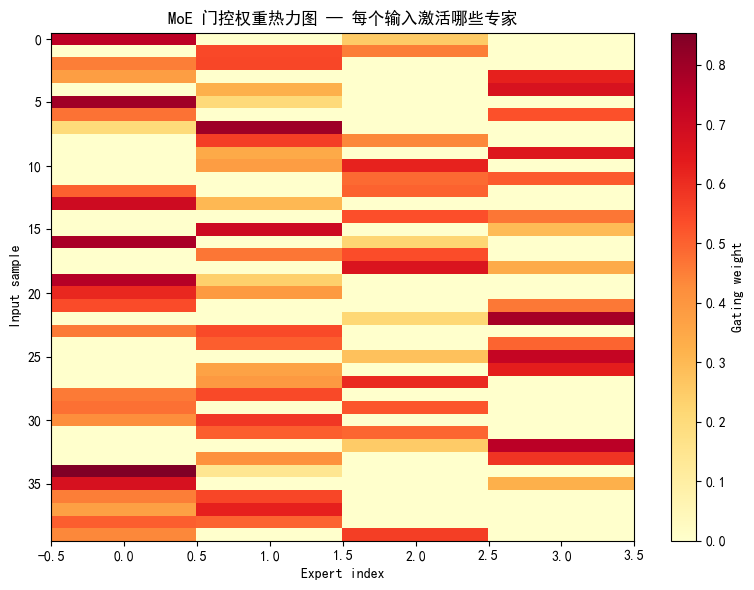

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

model.eval()
with torch.no_grad():
    # 生成一批示例输入（batch=8，序列长度=5）
    dummy_input = torch.randn(8, 5, d_model)
    moe_input = dummy_input.reshape(8 * 5, d_model)

    # 复现 MoE 门控计算，提取最终用于加权专家的 gating weights
    logits = model.moe_ffn.gate(moe_input)
    topk_vals, topk_indices = torch.topk(logits, model.moe_ffn.top_k, dim=1)
    mask = torch.full_like(logits, float('-inf'))
    mask.scatter_(1, topk_indices, topk_vals)
    gating_weights = F.softmax(mask, dim=1).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(gating_weights, cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Expert index')
ax.set_ylabel('Input sample')
ax.set_title('MoE 门控权重热力图 — 每个输入激活哪些专家')
fig.colorbar(im, ax=ax, label='Gating weight')
plt.tight_layout()
plt.show()


**可视化：专家利用率分布**

统计当前 batch 中每个专家被 top-k 选中的次数，检查负载是否均衡。

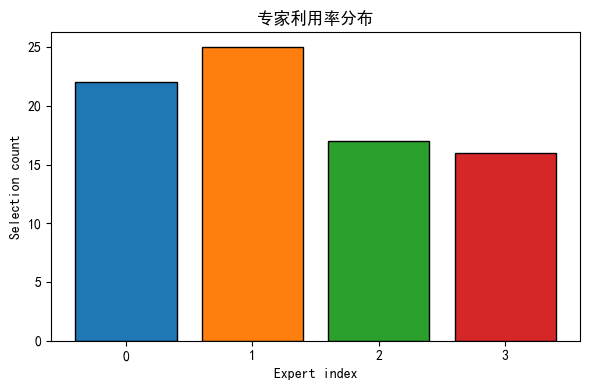

In [3]:
import matplotlib.pyplot as plt

# 统计 top-k 选择中每个专家被选中的次数
expert_counts = torch.zeros(model.moe_ffn.num_experts)
for idx in topk_indices.flatten():
    expert_counts[idx] += 1

fig, ax = plt.subplots(figsize=(6, 4))
colors = plt.cm.tab10(np.arange(model.moe_ffn.num_experts))
ax.bar(np.arange(model.moe_ffn.num_experts), expert_counts.numpy(), color=colors, edgecolor='k')
ax.set_xlabel('Expert index')
ax.set_ylabel('Selection count')
ax.set_title('专家利用率分布')
ax.set_xticks(np.arange(model.moe_ffn.num_experts))
plt.tight_layout()
plt.show()


## 总结

本示例展示了如何在 Transformer Block 中用 MoE 层替换标准的 FFN：
- **门控网络（Gate）**：为每个输入选择 top-k 专家。
- **专家网络（Experts）**：只处理被路由到自己这里的输入。
- **稀疏激活**：每个 token 只激活 k 个专家，从而在扩展模型容量的同时降低计算开销。
注意：优化器必须在 `loss.backward()` 之前创建，并在训练循环中按 `zero_grad -> forward -> backward -> step` 的顺序执行。